### 0. Setup & Reproducibility

In [26]:
import os
import random
import numpy as np

# Set random seeds for reproducibility globally
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Attempt to set seed for PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# Attempt to set seed for TensorFlow if available
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    tf.config.experimental.enable_op_determinism()
except ImportError:
    pass

print(f"Random seeds set to {SEED} for consistent results.")

Random seeds set to 42 for consistent results.


### 1. Data Loading

In [27]:
import pandas as pd
import os

path = r"..\Dataset"

print(f"Contents of the local dataset directory '{path}':")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

csv_path = os.path.join(path, 'phishing_email.csv')
df = pd.read_csv(csv_path)
print(df['label'].value_counts())

Contents of the local dataset directory '..\Dataset':
..\Dataset\CEAS_08.csv
..\Dataset\Enron.csv
..\Dataset\Ling.csv
..\Dataset\Nazario.csv
..\Dataset\Nigerian_Fraud.csv
..\Dataset\phishing_email.csv
..\Dataset\SpamAssasin.csv
label
1.0    42891
0.0    39595
Name: count, dtype: int64


In [28]:
dataframes = {}
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df_name = os.path.splitext(file)[0]
            file_path = os.path.join(root, file)

            if os.path.getsize(file_path) == 0:
                print(f"Skipping empty CSV: {file_path}")
                continue

            try:
                current_df = pd.read_csv(file_path)
            except pd.errors.EmptyDataError:
                print(f"Skipping empty CSV: {file_path}")
                continue

            if current_df.empty:
                print(f"Skipping empty DataFrame: {file_path}")
                continue

            dataframes[df_name] = current_df
            print(f"\n--- Loaded DataFrame: {df_name} ---")
            display(current_df.head())
            if 'label' in current_df.columns:
                print(f"Label distribution for {df_name}:")
                print(current_df['label'].value_counts())
            else:
                print(f"No 'label' column found in {df_name}.")

cleaned_dfs = []

for name, d in dataframes.items():
    temp_df = d.copy()

    if 'label' not in temp_df.columns:
        print(f"Skipping {name}: Missing label column.")
        continue

    text_like_cols = [col for col in temp_df.columns if col != 'label']
    if not text_like_cols:
        print(f"Skipping {name}: No content columns found.")
        continue

    temp_df[text_like_cols] = temp_df[text_like_cols].fillna("").astype(str)
    temp_df['text_combined'] = temp_df[text_like_cols].agg(' '.join, axis=1).str.replace(r'\s+', ' ', regex=True).str.strip()
    temp_df = temp_df[['text_combined', 'label']].copy()
    temp_df['label'] = pd.to_numeric(temp_df['label'], errors='coerce')
    temp_df = temp_df.dropna(subset=['label']).copy()
    temp_df['label'] = temp_df['label'].astype(int)
    temp_df['source'] = name

    cleaned_dfs.append(temp_df)
    print(f"Standardized {name}: {temp_df.shape}")

if not cleaned_dfs:
    raise ValueError("No datasets were standardized. Check the input CSV files.")

# Concatenate all cleaned dataframes into one merged dataset
df = pd.concat(cleaned_dfs, ignore_index=True)

# Remove rows with empty combined text
if 'text_combined' in df.columns:
    df['text_combined'] = df['text_combined'].fillna("").astype(str).str.strip()
    df = df[df['text_combined'] != ""].copy()

print(f"\nTotal merged rows: {len(df)}")
print(df['label'].value_counts())
display(df.head())


--- Loaded DataFrame: CEAS_08 ---


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


Label distribution for CEAS_08:
label
1    21842
0    17312
Name: count, dtype: int64

--- Loaded DataFrame: Enron ---


,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0


Label distribution for Enron:
label
0    15791
1    13976
Name: count, dtype: int64

--- Loaded DataFrame: Ling ---


...

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0.0
1,nom actual vols 24 th forwarded sabrae zajac h...,0.0
2,enron actuals march 30 april 1 201 estimated a...,0.0
3,hpl nom may 30 2001 see attached file hplno 53...,0.0
4,hpl nom june 1 2001 see attached file hplno 60...,0.0


Label distribution for phishing_email:
label
1.0    42891
0.0    39595
Name: count, dtype: int64

--- Loaded DataFrame: SpamAssasin ---


,sender,receiver,date,subject,body,label,urls
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700",Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0,1
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100",[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",0,1
2,"""Tim Chapman"" <timc@2ubh.com>",zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100",[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,0,1
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient: ;,"Thu, 22 Aug 2002 09:15:25 -0400",[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,0,1
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100",Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",0,1


Label distribution for SpamAssasin:
label
0    4091
1    1718
Name: count, dtype: int64
Standardized CEAS_08: (39154, 3)
Standardized Enron: (29767, 3)
Standardized Ling: (2859, 3)
Standardized Nigerian_Fraud: (3332, 3)
Standardized phishing_email: (82486, 3)
Standardized SpamAssasin: (5809, 3)

Total merged rows: 163406
label
1    84216
0    79190
Name: count, dtype: int64


,text_combined,label,source
0,Young Esposito <Young@iworld.de> user4@gvc.cea...,1,CEAS_08
1,Mok <ipline's1983@icable.ph> user2.2@gvc.ceas-...,1,CEAS_08
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,1,CEAS_08
3,Michael Parker <ivqrnai@pobox.com> SpamAssassi...,0,CEAS_08
4,Gretchen Suggs <externalsep1@loanofficertool.c...,1,CEAS_08


### 1.1 Data Standardization and Merging


In [29]:
# Legacy merge cell kept for compatibility when running the notebook top-to-bottom.
# The main standardized merge is already created in the previous cell.
if 'df' not in globals() or 'text_combined' not in df.columns:
    cleaned_dfs = []

    for name, d in dataframes.items():
        temp_df = d.copy()

        if 'label' not in temp_df.columns:
            print(f"Skipping {name}: Missing label column.")
            continue

        text_like_cols = [col for col in temp_df.columns if col != 'label']
        if not text_like_cols:
            print(f"Skipping {name}: No content columns found.")
            continue

        temp_df[text_like_cols] = temp_df[text_like_cols].fillna("").astype(str)
        temp_df['text_combined'] = temp_df[text_like_cols].agg(' '.join, axis=1).str.replace(r'\s+', ' ', regex=True).str.strip()
        temp_df = temp_df[['text_combined', 'label']].copy()
        temp_df['label'] = pd.to_numeric(temp_df['label'], errors='coerce')
        temp_df = temp_df.dropna(subset=['label']).copy()
        temp_df['label'] = temp_df['label'].astype(int)
        temp_df['source'] = name

        cleaned_dfs.append(temp_df)
        print(f"Standardized {name}: {temp_df.shape}")

    if not cleaned_dfs:
        raise ValueError("No datasets were standardized. Check the input CSV files.")

    df = pd.concat(cleaned_dfs, ignore_index=True)
    df['text_combined'] = df['text_combined'].fillna("").astype(str).str.strip()
    df = df[df['text_combined'] != ""].copy()

print(f"\nTotal merged rows: {len(df)}")
print(df['label'].value_counts())
display(df.head())


Total merged rows: 163406
label
1    84216
0    79190
Name: count, dtype: int64


,text_combined,label,source
0,Young Esposito <Young@iworld.de> user4@gvc.cea...,1,CEAS_08
1,Mok <ipline's1983@icable.ph> user2.2@gvc.ceas-...,1,CEAS_08
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,1,CEAS_08
3,Michael Parker <ivqrnai@pobox.com> SpamAssassi...,0,CEAS_08
4,Gretchen Suggs <externalsep1@loanofficertool.c...,1,CEAS_08


### 2. Data Cleaning - Duplicates

# Remove Duplicates

In [30]:
print("--- Remove Duplicates ---")

rows_before = len(df)
duplicate_rows_before = df.duplicated().sum()

print(f"Rows before: {rows_before}")
print(f"Duplicate rows found: {duplicate_rows_before}")

# Remove duplicate rows
df = df.drop_duplicates().copy()

rows_after = len(df)
duplicate_rows_after = df.duplicated().sum()
removed_duplicates = rows_before - rows_after

print(f"Rows after: {rows_after}")
print(f"Duplicate rows after cleaning: {duplicate_rows_after}")
print(f"Removed duplicate rows: {removed_duplicates}")

--- Remove Duplicates ---
Rows before: 163406
Duplicate rows found: 757
Rows after: 162649
Duplicate rows after cleaning: 0
Removed duplicate rows: 757


### 3. Final Cleaning Check

In [31]:
print("--- Final Cleaning Check ---")
print(f"Final rows: {len(df)}")
print(f"Remaining duplicate rows: {int(df.duplicated().sum())}")
print(f"Remaining missing values: {int(df.isna().sum().sum())}")

df.head()

--- Final Cleaning Check ---
Final rows: 162649
Remaining duplicate rows: 0
Remaining missing values: 0


,text_combined,label,source
0,Young Esposito <Young@iworld.de> user4@gvc.cea...,1,CEAS_08
1,Mok <ipline's1983@icable.ph> user2.2@gvc.ceas-...,1,CEAS_08
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,1,CEAS_08
3,Michael Parker <ivqrnai@pobox.com> SpamAssassi...,0,CEAS_08
4,Gretchen Suggs <externalsep1@loanofficertool.c...,1,CEAS_08


### 4. Exploratory Data Analysis (EDA)
Let's visualize the distribution of labels and the length of the email text to identify any patterns.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Jay\AppData\Local\Temp\ipykernel_9380\2128107272.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[0], palette='viridis')


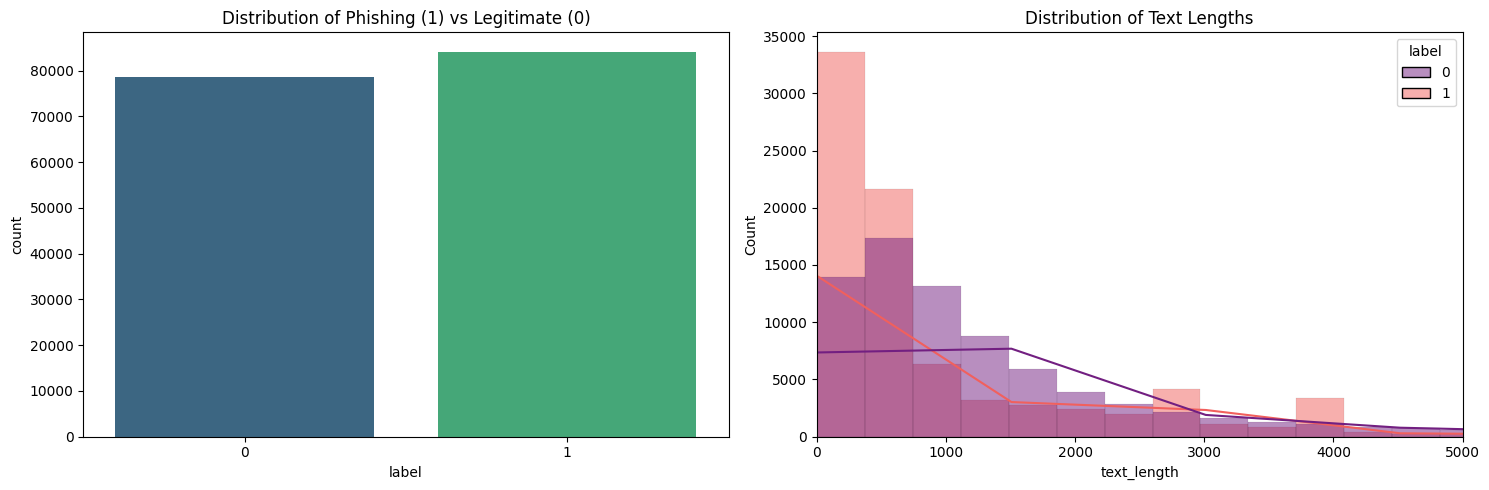

In [32]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate text length
df['text_length'] = df['text_combined'].astype(str).apply(len)

# Set up plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Label Distribution
sns.countplot(data=df, x='label', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Phishing (1) vs Legitimate (0)')

# Plot 2: Text Length Distribution
sns.histplot(data=df, x='text_length', hue='label', kde=True, ax=axes[1], palette='magma')
axes[1].set_title('Distribution of Text Lengths')
axes[1].set_xlim(0, 5000) # Limiting x-axis for better visibility of the bulk of data

plt.tight_layout()
plt.show()

### 5. Model Preparation
Next, we'll split the data into training and testing sets, then use TF-IDF to vectorize the text data for a classifier like Random Forest or Logistic Regression.

In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prefer source-aware splitting to reduce data leakage across datasets.
if 'source' in df.columns and df['source'].nunique() >= 3:
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_val_idx, test_idx = next(gss_outer.split(df, y=df['label'], groups=df['source']))

    train_val_df = df.iloc[train_val_idx].copy()
    test_df = df.iloc[test_idx].copy()

    if train_val_df['source'].nunique() >= 2:
        gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
        train_idx, val_idx = next(gss_inner.split(train_val_df, y=train_val_df['label'], groups=train_val_df['source']))
        train_df = train_val_df.iloc[train_idx].copy()
        val_df = train_val_df.iloc[val_idx].copy()
    else:
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=0.125,
            random_state=42,
            stratify=train_val_df['label']
        )

    split_mode = 'source-aware'
else:
    # Fallback for cases with missing/insufficient source groups.
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.125,
        random_state=42,
        stratify=train_val_df['label']
    )
    split_mode = 'random stratified (fallback)'

X_train = train_df['text_combined'].astype(str).tolist()
X_val = val_df['text_combined'].astype(str).tolist()
test_texts = test_df['text_combined'].astype(str).tolist()

y_train = train_df['label'].astype(int).tolist()
y_val = val_df['label'].astype(int).tolist()
y_test = test_df['label'].astype(int).tolist()

# Vectorize text for all model cells.
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(test_texts)

print(f"Split mode: {split_mode}")
print(f'Training set size: {X_train_tfidf.shape}')
print(f'Validation set size: {X_val_tfidf.shape}')
print(f'Testing set size: {X_test_tfidf.shape}')

### 5.1 Baseline Reference
This baseline is the minimum benchmark. All trained models should beat it on fraud-focused metrics.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- Baseline: Majority Class ---")
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train_tfidf, y_train)
baseline_pred = baseline_model.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall:    {baseline_recall:.4f}")
print(f"Baseline F1:        {baseline_f1:.4f}")

--- Baseline: Majority Class ---
Baseline Accuracy:  0.4781
Baseline Precision: 0.0000
Baseline Recall:    0.0000
Baseline F1:        0.0000


### 6. Model Training & Evaluation


6.1 Random Forest Classifier

In [ ]:
print("--- 6.1 Random Forest Classifier ---")
# Initialize and train the classifier with slightly fewer estimators for speed
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_pred)

# Print evaluation metrics
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {test_acc:.4f}")

--- 6.1 Random Forest Classifier ---
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     32786
           1       1.00      0.91      0.95     35791

    accuracy                           0.95     68577
   macro avg       0.95      0.95      0.95     68577
weighted avg       0.96      0.95      0.95     68577

Accuracy: 0.9526


#### 6.2 XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

print("--- 6.2 XGBoost Classifier ---")
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb_model.predict(X_test_tfidf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {xgb_acc:.4f}")

--- 6.2 XGBoost Classifier ---
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     32786
           1       0.98      0.95      0.97     35791

    accuracy                           0.97     68577
   macro avg       0.97      0.97      0.97     68577
weighted avg       0.97      0.97      0.97     68577

Accuracy: 0.9654


#### 6.3 Multinomial Naive Bayes

#### 6.4 K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("--- 6.4 K-Nearest Neighbors ---")
# Initialize and train the classifier
knn_model = KNeighborsClassifier(n_neighbors=5) # You can adjust n_neighbors
knn_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_tfidf)
knn_acc = accuracy_score(y_test, y_pred_knn)

# Print evaluation metrics
print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))
print(f"Accuracy: {knn_acc:.4f}")

--- 6.4 K-Nearest Neighbors ---
K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.64      0.78     32786
           1       0.75      1.00      0.86     35791

    accuracy                           0.82     68577
   macro avg       0.87      0.82      0.82     68577
weighted avg       0.87      0.82      0.82     68577

Accuracy: 0.8250


In [ ]:
from sklearn.naive_bayes import MultinomialNB

print("--- 6.3 Multinomial Naive Bayes ---")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))
print(f"Accuracy: {nb_acc:.4f}")

--- 6.3 Multinomial Naive Bayes ---
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     32786
           1       0.98      0.87      0.92     35791

    accuracy                           0.92     68577
   macro avg       0.93      0.93      0.92     68577
weighted avg       0.93      0.92      0.92     68577

Accuracy: 0.9248


### 7. Final Model Comparison Summary
This table summarizes the performance of all classifiers tested on the phishing email dataset.

In [ ]:
import pandas as pd

results = []

if 'test_acc' in globals():
    results.append({'Model': 'Random Forest', 'Accuracy': test_acc})
if 'y_pred_xgb' in globals() and 'y_test' in globals():
    results.append({'Model': 'XGBoost', 'Accuracy': accuracy_score(y_test, y_pred_xgb)})
if 'nb_acc' in globals():
    results.append({'Model': 'Multinomial Naive Bayes', 'Accuracy': nb_acc})
if 'knn_acc' in globals():
    results.append({'Model': 'K-Nearest Neighbors', 'Accuracy': knn_acc})
if 'baseline_acc' in globals():
    results.append({'Model': 'Baseline (Most Frequent)', 'Accuracy': baseline_acc})

if not results:
    raise ValueError("No model results found. Run baseline/model training cells first.")

comparison_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

try:
    display(comparison_df.style.background_gradient(cmap='magma'))
except Exception:
    display(comparison_df)

,Model,Accuracy
1,XGBoost,0.965382
0,Random Forest,0.952593
2,Multinomial Naive Bayes,0.924800
3,K-Nearest Neighbors,0.825000
4,Baseline (Most Frequent),0.478090


### 7.1 Test Gate (Pass/Fail)
Run this after model training cells to verify whether models beat baseline and satisfy fraud-focused checks.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print('--- Test Gate ---')

required = ['y_test', 'baseline_acc']
missing_required = [v for v in required if v not in globals()]
if missing_required:
    print(f"Missing required variables: {missing_required}. Run data split and baseline cells first.")
else:
    model_predictions = {
        'Random Forest': 'y_pred',
        'XGBoost': 'y_pred_xgb',
        'K-Nearest Neighbors': 'y_pred_knn',
        'Multinomial Naive Bayes': 'y_pred_nb'
    }

    rows = []
    for model_name, pred_var in model_predictions.items():
        if pred_var in globals():
            preds = globals()[pred_var]
            rows.append({
                'Model': model_name,
                'Accuracy': accuracy_score(y_test, preds),
                'Fraud Precision': precision_score(y_test, preds, zero_division=0),
                'Fraud Recall': recall_score(y_test, preds, zero_division=0),
                'Fraud F1': f1_score(y_test, preds, zero_division=0)
            })

    if not rows:
        print('No model predictions found yet. Run the model training cells first, then run this test gate again.')
    else:
        metrics_df = pd.DataFrame(rows).sort_values(by='Accuracy', ascending=False)
        display(metrics_df)

        best = metrics_df.iloc[0]
        pass_baseline = best['Accuracy'] > baseline_acc
        pass_f1 = best['Fraud F1'] >= 0.90
        pass_recall = best['Fraud Recall'] >= 0.90

        print(f"Baseline Accuracy: {baseline_acc:.4f}")
        print(f"Best Model: {best['Model']}")
        print(f"Best Accuracy: {best['Accuracy']:.4f}")
        print(f"Best Fraud F1: {best['Fraud F1']:.4f}")
        print(f"Best Fraud Recall: {best['Fraud Recall']:.4f}")

        print(f"Pass baseline check (best_acc > baseline_acc): {pass_baseline}")
        print(f"Pass fraud F1 >= 0.90: {pass_f1}")
        print(f"Pass fraud recall >= 0.90: {pass_recall}")

        overall_pass = pass_baseline and pass_f1 and pass_recall
        print(f"OVERALL TEST GATE: {'PASS' if overall_pass else 'FAIL'}")

--- Test Gate ---


,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1
1,XGBoost,0.965382,0.978411,0.954737,0.966429
0,Random Forest,0.952593,0.997401,0.911542,0.952541
3,Multinomial Naive Bayes,0.924800,0.980428,0.873348,0.923795
2,K-Nearest Neighbors,0.825000,0.750527,0.995641,0.855880


Baseline Accuracy: 0.4781
Best Model: XGBoost
Best Accuracy: 0.9654
Best Fraud F1: 0.9664
Best Fraud Recall: 0.9547
Pass baseline check (best_acc > baseline_acc): True
Pass fraud F1 >= 0.90: True
Pass fraud recall >= 0.90: True
OVERALL TEST GATE: PASS


# 8. Overfitting Check & Confusion Matrix Random Forest Classifier

Training Accuracy: 0.9999
Testing Accuracy:  0.9526
Difference:        0.0473


<Figure size 800x600 with 0 Axes>

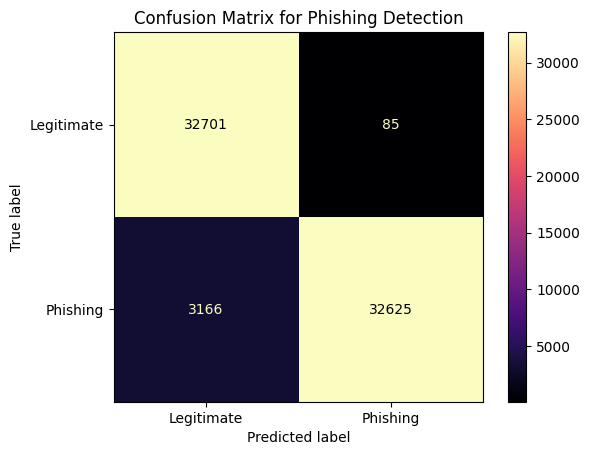

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate accuracy on training set
train_pred = rf_model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Difference:        {train_acc - test_acc:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='magma')
plt.title('Confusion Matrix for Phishing Detection')
plt.show()

### 8. Word Cloud Visualization

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


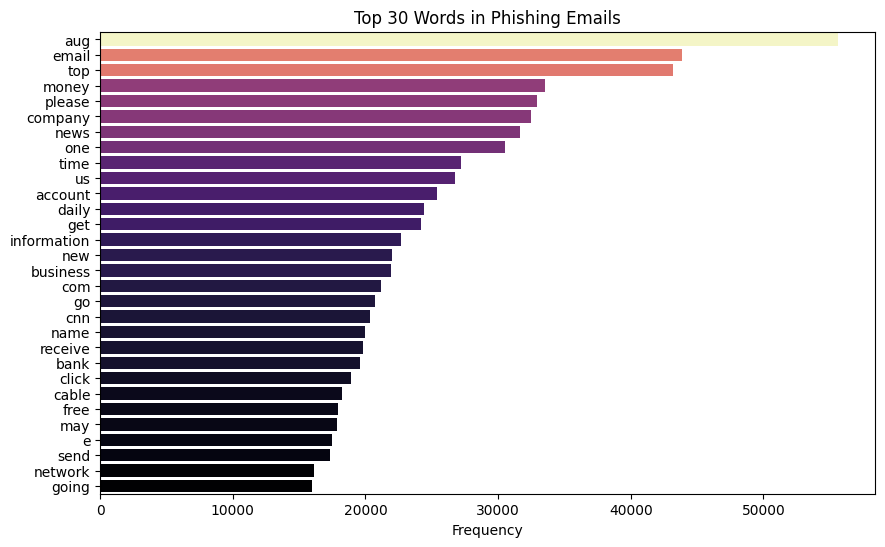

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Fix: Use 'text_combined' instead of 'text'
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split()

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words]

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(counts), palette='magma', legend=False)
plt.title('Top 30 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

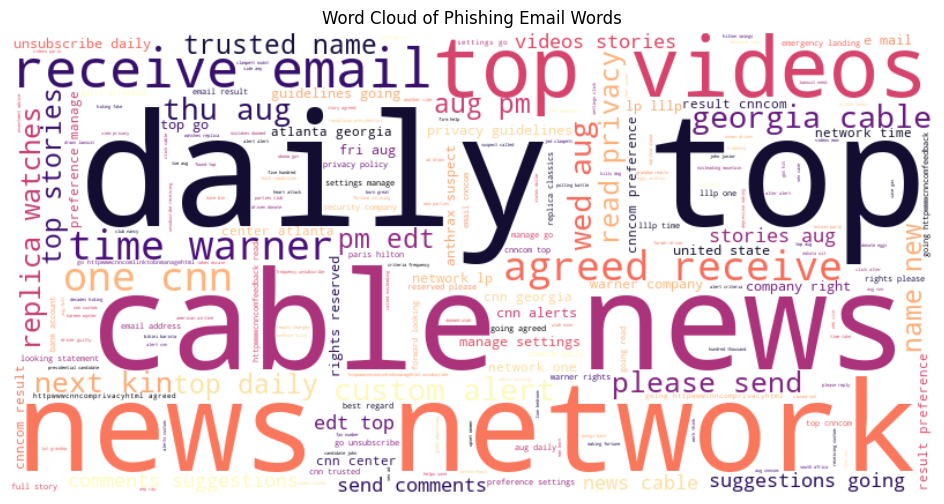

In [ ]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()